In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep='\t',
    names=['label', 'message']
)

In [24]:
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [25]:
df['label'] = df['label'].map({'ham' : 0,'spam' : 1})

In [26]:
print(df['label'])

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: label, Length: 5572, dtype: int64


 **Converting text to Numbers**

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [28]:
cv = CountVectorizer()

In [29]:
X = cv.fit_transform(df['message'])

In [30]:
y = df['label']

In [34]:
from sklearn.decomposition import PCA

In [35]:
pca = PCA(n_components=2)

In [36]:
X_pca = pca.fit_transform(X.toarray())

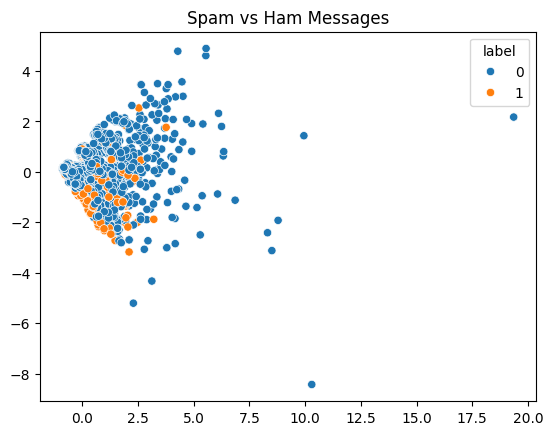

In [37]:
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['label']
)

plt.title("Spam vs Ham Messages")
plt.show()

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.svm import SVC

In [45]:
from sklearn.metrics import accuracy_score

In [46]:
model = SVC(kernel='rbf')

In [47]:
model.fit(X_train,y_train)

SVC()

In [48]:
y_pred = model.predict(X_test)

In [49]:
accuracy = accuracy_score(y_test, y_pred)

In [51]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.9829596412556054


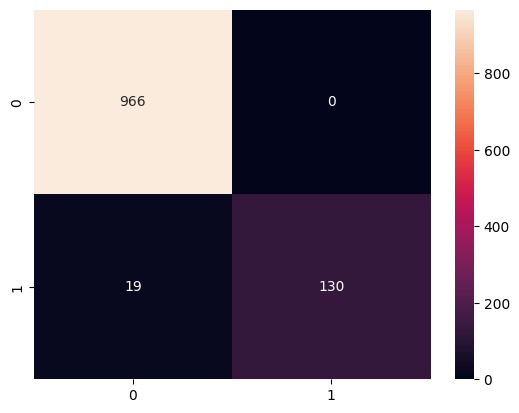

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

In [53]:
print(accuracy * 100)

98.29596412556054
